In [1]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, DBSCAN
from agcounts_filter import convert_AC
from datetime import datetime
from scipy.stats import mode

Récupération des données et des annotations

In [ ]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)


# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []

#Parcourir les fichiers CSV
for file in folder[0:4]: #[0:7]
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":
        # Récupération des noms des colonnes pour pouvoir lire le fichier (pas le m^me pour tous)
        csv_file_column = pd.read_csv(folder_path + "/" + file, skiprows=5, sep = ',', low_memory = False)
        lst_column = list(csv_file_column)

        # Les fichiers n'ont pas tous le même nombre de données
        if lst_column == ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"]:
            data_file = pd.read_csv(folder_path + "/" + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"], dtype = {"Event":str},low_memory=False)
        elif lst_column == ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Quat W', 'Quat X', 'Quat Y', 'Quat Z', 'Unnamed: 11']:
            data_file = pd.read_csv(folder_path + "/" + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Quat W","Quat X","Quat Y","Quat Z"],low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_AC = dom_AC["AC"].tolist() # Conversion du type pd.serie en type list
            for ac in list_dom_AC :
                X_non_dom.append(ac)

        elif file[-7:-4] == "dom":
            list_dom_AC = dom_AC["AC"].tolist()
            for ac in list_dom_AC:
                X_dom.append(ac)

        

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                start_dom = int(round(float(my_sheet.cell(label.row,13).value))) - 1
                # Décalage pour synchroniser X et Y
                for decalage in range(start_dom):
                    Y_dom.append(None)
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                start_non_dom = int(round(float(my_sheet.cell(label.row,13).value))) - 1
                # Décalage pour synchroniser X et Y
                for decalage in range(start_non_dom):
                    Y_non_dom.append(None)
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0, difference):
                        Y_dom.append(None) 
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_dom.append("mouvement")
                    elif label.value[3:13] == "sédentaire":
                        Y_dom.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom.append(None) 

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None)

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_non_dom.append("mouvement")
                    elif label.value[3:13] == "sédentaire":
                        Y_non_dom.append("non mouvement")                    
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)
                        

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        # CROPER X A LA LONGUEUR DE Y 
        X_dom = X_dom[:len(Y_dom)] 
        X_non_dom = X_non_dom[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(X_dom) ]
        Y_non_dom = Y_non_dom[:len(X_non_dom) ]




On est dans le fichier : Data_11_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_11_X.xlsx
len(X_dom) 26807
X_dom [150.86417732516887, 217.86693186438367, 104.95713410721541, 86.21484790916237, 141.8238343861849, 268.83452159274486, 216.61486560252507, 25.238858928247925, 23.600847442411894, 42.20189569201838, 15.0, 50.695167422546305, 62.289646009589745, 1.4142135623730951, 55.08175741568164, 75.39230729988306, 48.41487374764082, 61.66036003787198, 170.79227148791014, 136.61991070118586, 20.0, 0.0, 210.440015206234, 108.72442227944924, 305.4995908344232, 69.42621983083913, 75.21303078589507, 326.1977927577071]
Y_dom ['mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'non mouvement', 'mouvement', 'mouvement', 'mouvement', 'mouvement', 'm

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 103.60019305001319, 78.89233169326408, 39.11521443121589, 65.76473218982953, 64.8459713474939, 97.0051545022222, 145.12063946937388, 25.709920264364882, 53.907327887774215, 104.35516278555652, 85.42833253669417, 45.17742799230607, 106.17438485811914, 137.05838172107534, 165.19685227025363, 63.631753079732135, 214.15881957089695, 88.86506625215557, 30.0, 299.54799281584246, 175.84083712266613, 447.97321348491363, 103.0970416646375, 169.75570682601514, 135.60235986147143, 115.48592987892508, 54.0, 22.0, 37.44329045369811, 84.59905436823747, 83.35466393669883, 131.55227098001768, 78.89233169326408, 278.22652641328074, 156.1089363233252, 198.27506146764904, 206.46065000382035, 89.94442728707543, 26.0, 30.479501308256342, 94.11163583744573, 63.655321851358195, 151.7003625572464, 44.654227123532216, 60.0, 123.17467272130257, 173.95401691251627, 152.502

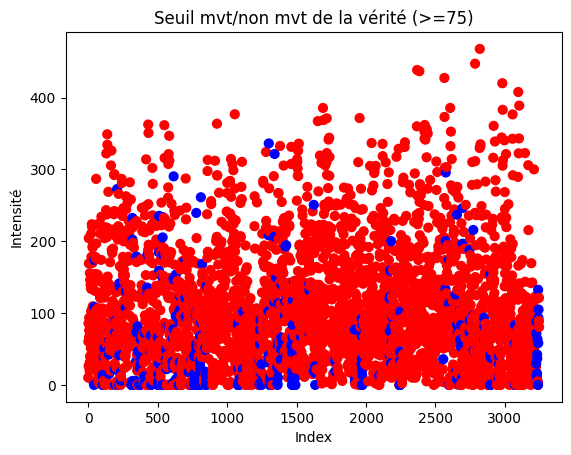

In [12]:
# Convertir en array pour faciliter le filtrage
X_array = np.array(X_dom)
Y_array = np.array(Y_dom)
print(X_dom)

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None = Y_array != None
print(mask_None)
# Appliquer le masque
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]


# Affichage : colorisation des points en fonction de la classe (vétié)
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
colors = [label_to_color[y] for y in Y_clean]

plt.scatter(range(len(X_clean)), X_clean, c=colors, s=40) #plt.scatter(range(len(X_clean[0:400])), X_clean[0:400], c=colors, s=40)
plt.title("Seuil mvt/non mvt de la vérité (>=75)") 
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()


Analyse métriques

3247


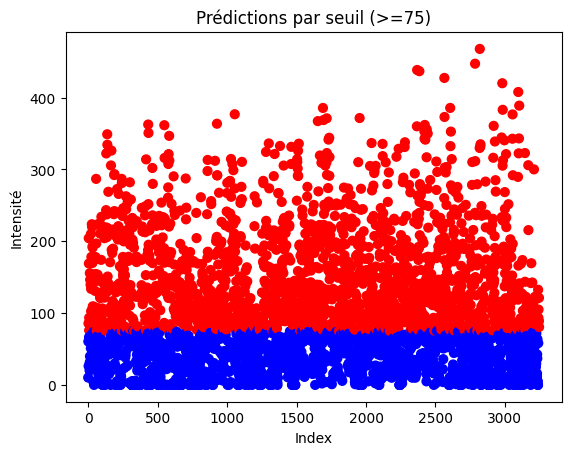

Accuracy pour seuil > 75 : 0.61


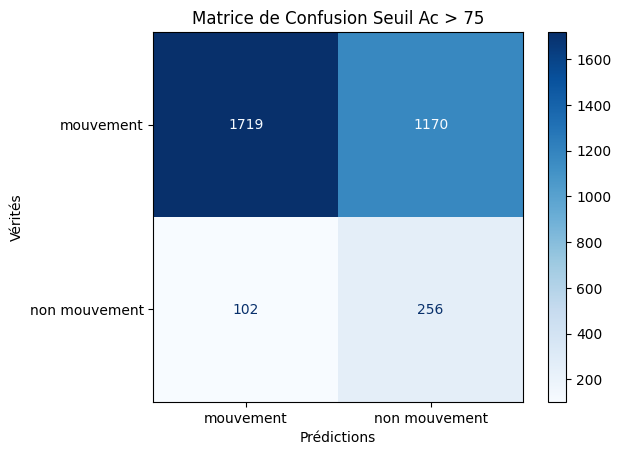

In [13]:
# Convertir en array pour faciliter le filtrage
X_array = np.array(X_dom)
Y_array = np.array(Y_dom)
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_None = Y_array != None
# Appliquer le masque
X_clean = X_array[mask_None]
Y_clean = Y_array[mask_None]

X_flat = np.vstack(X_clean)
Y_flat = np.vstack(Y_clean)

# PAS BESOIN D'EQUILIBRER LES DONNEES ?
#Equilibrer les données : autant de mouvement que de non mouvement, et dans le meme ordre que X_array et Y_array


#********************************* Seuil AC > 75 **********************************************************************************
#On a X_dom et Y_dom : construire un Y_pred_2 et le comparer à Y_dom
Y_pred_75 = []

for idx_data in range(0,len(X_flat)):
    #seuil = X_flat[idx_data] + X_flat[idx_data+1] # //////////////////////////
    seuil = X_flat[idx_data]
    if seuil >= 75 :
        Y_pred_75.append("mouvement")
    elif seuil < 75 :
        Y_pred_75.append("non mouvement")
    else:
        Y_pred_75.append(None)

print(len(X_flat))

# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue'}
colors = [label_to_color[y] for y in Y_pred_75]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(X_flat)), X_flat[:, 0], c=colors, s=40)
plt.title("Prédictions par seuil (>=75)")
plt.xlabel("Index")
plt.ylabel("Intensité")
plt.show()

# Evaluate the model
accuracy = accuracy_score(Y_flat, Y_pred_75)
print(f"Accuracy pour seuil > 75 : {accuracy:.2f}")
cm_75 = confusion_matrix(Y_flat, Y_pred_75)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm_75, display_labels= ["mouvement", "non mouvement"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Matrice de Confusion Seuil Ac > 75")
disp.ax_.set_xlabel("Prédictions")
disp.ax_.set_ylabel("Vérités")
#disp.figure_.show()
plt.show()